# Long-Term Care Hospital Quality Analysis
## CMS Provider Data – Predicting Discharge-to-Community Performance

---
**Course:** Udacity Data Scientist Nanodegree  
**Process:** CRISP-DM  
**Dataset:** CMS Long-Term Care Hospital (LTCH) Provider Data  
**Target Variable:** Discharge to Community Comparative Performance

---
### Questions
1. Is it infection control, cost efficiency, or patient rehabilitation that best predicts whether an LTCH successfully discharges patients home?
2. Are there regional patterns in LTCH discharge performance — and do better-performing hospitals share common clinical characteristics?
3. How accurately can a machine learning model predict a hospital's comparative discharge performance?
4. What would happen in a creative predictive scenario using our trained model?

In [2]:
# ── Standard libraries ────────────────────────────────────────────────────────
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
)

# ── Global settings ───────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
RANDOM_STATE = 42

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Business Understanding (CRISP-DM Step 1)

Long-Term Care Hospitals (LTCHs) specialise in treating patients who need **extended
hospital-level care** — typically 25+ days.

### Why does 'Discharge to Community' matter?
A patient successfully discharged to home or community-based care is the ultimate goal.
CMS compares each hospital against a national rate:

| Classification | Meaning |
|---|---|
| **Better than the National Rate** | Hospital outperforms the national average |
| **No Different than the National Rate** | Performance is statistically comparable |
| **Worse than the National Rate** | Hospital underperforms the national average |

In [8]:
# ── Load raw data ─────────────────────────────────────────────────────────────
# Upload the CSV file to your workspace first!
# File: Long-Term_Care_Hospital-Provider_Data_Sep2026_2__1_.csv

FILE_PATH = "Long-Term_Care_Hospital-Provider_Data_Sep2026_2 (1).csv"
df_raw = pd.read_csv(FILE_PATH, dtype="string")

print(f"Shape            : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Unique hospitals : {df_raw['CMS Certification Number (CCN)'].nunique()}")
print(f"Unique measures  : {df_raw['Measure Code'].nunique()}")
print(f"States covered   : {df_raw['State'].nunique()}")
print(f"CMS Regions      : {sorted(df_raw['CMS Region'].unique())}")
df_raw.head(5)

Shape            : 24,258 rows x 16 columns
Unique hospitals : 311
Unique measures  : 78
States covered   : 47
CMS Regions      : ['1', '10', '2', '3', '4', '5', '6', '7', '8', '9']


,CMS Certification Number (CCN),Provider Name,Address Line 1,Address Line 2,City/Town,State,ZIP Code,County/Parish,Telephone Number,CMS Region,Measure Code,Score,Footnote,Start Date,End Date,Measure Date Range
0,012006,INFIRMARY LTAC HOSPITAL,5 MOBILE INFIRMARY CIRCLE,-,MOBILE,AL,36607,Mobile,(251) 660-5611,4,L_006_01_CI_LOWER,0.729,-,10/01/2024,09/30/2025,-
1,012006,INFIRMARY LTAC HOSPITAL,5 MOBILE INFIRMARY CIRCLE,-,MOBILE,AL,36607,Mobile,(251) 660-5611,4,L_006_01_CI_UPPER,4.410,-,10/01/2024,09/30/2025,-
2,012006,INFIRMARY LTAC HOSPITAL,5 MOBILE INFIRMARY CIRCLE,-,MOBILE,AL,36607,Mobile,(251) 660-5611,4,L_006_01_COMP_PERF,No Different than the National Benchmark,-,10/01/2024,09/30/2025,-
3,012006,INFIRMARY LTAC HOSPITAL,5 MOBILE INFIRMARY CIRCLE,-,MOBILE,AL,36607,Mobile,(251) 660-5611,4,L_006_01_DOPC_DAYS,"2,418",-,10/01/2024,09/30/2025,-
4,012006,INFIRMARY LTAC HOSPITAL,5 MOBILE INFIRMARY CIRCLE,-,MOBILE,AL,36607,Mobile,(251) 660-5611,4,L_006_01_ELIGCASES,2.513,-,10/01/2024,09/30/2025,-


In [9]:
# ── Understand the Score column ───────────────────────────────────────────────
# The Score column holds mixed content:
# - Numeric values (sometimes with commas e.g. '2,418')
# - 'Not Available' (missing data)
# - Categorical labels (for COMP_PERF measures)

not_avail_count = (df_raw["Score"] == "Not Available").sum()
numeric_mask = pd.to_numeric(
    df_raw["Score"].str.replace(",", "", regex=False), errors="coerce"
).notna()

print(f"Numeric-like scores : {numeric_mask.sum():,}")
print(f"'Not Available'     : {not_avail_count:,}")
print()
print("Categorical values in Score:")
other = df_raw.loc[
    ~numeric_mask & (df_raw["Score"] != "Not Available"), "Score"
].value_counts()
print(other.to_string())

Numeric-like scores : 21,208
'Not Available'     : 1,766

Categorical values in Score:
Score
No Different than the National Rate         499
No Different than the National Benchmark    462
Better than the National Benchmark          210
Worse than the National Rate                 48
Better than the National Rate                37
Worse than the National Benchmark            28


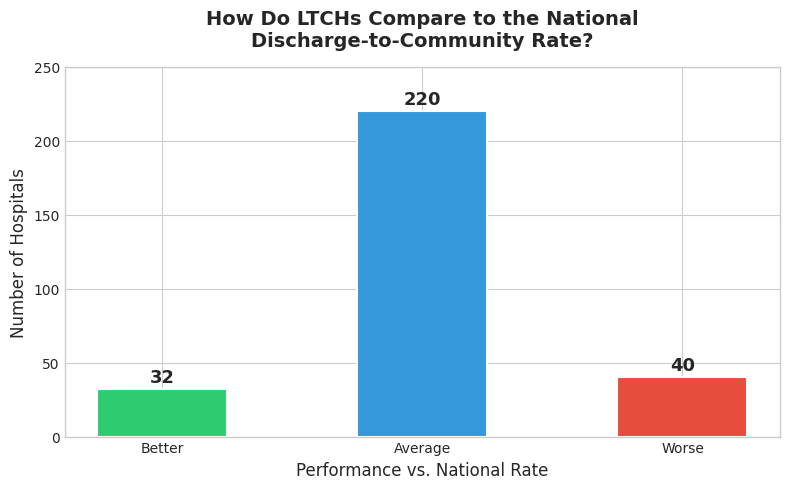

Figure saved: fig_target_distribution.png


In [10]:
# ── Target variable distribution ──────────────────────────────────────────────
TARGET_CODE = "L_018_02_DTC_COMP_PERF"

TARGET_MAP = {
    "Better than the National Rate": "Better",
    "No Different than the National Rate": "Average",
    "Worse than the National Rate": "Worse",
}

df_target = df_raw[df_raw["Measure Code"] == TARGET_CODE][
    ["CMS Certification Number (CCN)", "Provider Name", "State", "CMS Region", "Score"]
].copy()
df_target["Performance"] = df_target["Score"].map(TARGET_MAP)

counts = df_target["Performance"].value_counts().reindex(["Better", "Average", "Worse"])
colors = ["#2ecc71", "#3498db", "#e74c3c"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white",
              linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(val), ha="center", va="bottom", fontsize=13, fontweight="bold")

ax.set_title("How Do LTCHs Compare to the National\nDischarge-to-Community Rate?",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Performance vs. National Rate", fontsize=12)
ax.set_ylabel("Number of Hospitals", fontsize=12)
ax.set_ylim(0, counts.max() + 30)
plt.tight_layout()
plt.savefig("fig_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_target_distribution.png")

---
## 2.Data Preparation (CRISP-DM Step 3)

We pivot the long-format data into **wide format** (one row per hospital, one column per feature).

###  Data Leakage Prevention
We exclude all other `L_018_02_*` sub-measures because they describe the same outcome
as our target. Using them would make the model artificially accurate but useless in practice.

In [11]:
# ── Feature codes (no leakage from L_018_02) ──────────────────────────────────
FEATURE_CODES = {
    "L_006_01_SIR"               : "clabsi_sir",
    "L_006_01_DOPC_DAYS"         : "clabsi_dopc_days",
    "L_006_01_ELIGCASES"         : "clabsi_eligcases",
    "L_007_01_SIR"               : "cauti_sir",
    "L_007_01_DOPC_DAYS"         : "cauti_dopc_days",
    "L_007_01_ELIGCASES"         : "cauti_eligcases",
    "L_014_01_SIR"               : "mrsa_sir",
    "L_014_01_DOPC_DAYS"         : "mrsa_dopc_days",
    "L_014_01_ELIGCASES"         : "mrsa_eligcases",
    "L_017_01_PPR_PD_RSRR"       : "readmission_rsrr",
    "L_017_01_PPR_PD_VOLUME"     : "readmission_volume",
    "L_019_01_MSPB_SCORE"        : "mspb_score",
    "L_019_01_MSPB_NUMB"         : "mspb_episodes",
    "L_011_06_ADJ_CHG_MOBL_SCORE": "mobility_adj_score",
    "L_011_06_DENOMINATOR"       : "mobility_denominator",
}

print(f"Selected {len(FEATURE_CODES)} feature measures.")


def parse_score(series):
    """Convert Score strings to numeric float.

    Handles comma-separated thousands ('2,418' -> 2418.0),
    'Not Available' -> NaN, and standard numeric strings.

    Args:
        series (pd.Series): Raw Score column (string dtype).

    Returns:
        pd.Series: float64 values.
    """
    cleaned = series.str.replace(",", "", regex=False)
    cleaned = cleaned.replace("Not Available", np.nan)
    return pd.to_numeric(cleaned, errors="coerce")


def build_feature_matrix(df, feature_codes, target_code):
    """Pivot long-format CMS data into a wide feature matrix.

    Each row = one hospital, each column = one measure or metadata field.

    Args:
        df (pd.DataFrame): Raw long-format DataFrame (all dtypes string).
        feature_codes (dict): Mapping of Measure Code -> clean column name.
        target_code (str): Measure Code for the target variable.

    Returns:
        pd.DataFrame: Wide-format DataFrame ready for ML.
    """
    ccn_col = "CMS Certification Number (CCN)"

    # Hospital metadata (one row per hospital)
    meta_cols = [ccn_col, "Provider Name", "State", "CMS Region"]
    meta = (
        df[meta_cols]
        .drop_duplicates(subset=[ccn_col])
        .set_index(ccn_col)
    )

    # Target variable
    target_df = (
        df[df["Measure Code"] == target_code][[ccn_col, "Score"]]
        .set_index(ccn_col)
        .rename(columns={"Score": "target_raw"})
    )

    # Numeric features
    feature_frames = []
    for mcode, colname in feature_codes.items():
        sub = (
            df[df["Measure Code"] == mcode][[ccn_col, "Score"]]
            .set_index(ccn_col)
            .rename(columns={"Score": colname})
        )
        sub[colname] = parse_score(sub[colname])
        feature_frames.append(sub)

    features = pd.concat(feature_frames, axis=1)

    # Join everything
    wide = meta.join(target_df, how="inner").join(features, how="left")
    wide["CMS Region"] = pd.to_numeric(wide["CMS Region"], errors="coerce")
    return wide


df_wide = build_feature_matrix(df_raw, FEATURE_CODES, TARGET_CODE)
print(f"Wide table shape: {df_wide.shape}")
df_wide.head(3)

Selected 15 feature measures.
Wide table shape: (311, 19)


,Provider Name,State,CMS Region,target_raw,clabsi_sir,clabsi_dopc_days,clabsi_eligcases,cauti_sir,cauti_dopc_days,cauti_eligcases,mrsa_sir,mrsa_dopc_days,mrsa_eligcases,readmission_rsrr,readmission_volume,mspb_score,mspb_episodes,mobility_adj_score,mobility_denominator
CMS Certification Number (CCN),,,,,,,,,,,,,,,,,,,
012006,INFIRMARY LTAC HOSPITAL,AL,4,No Different than the National Rate,1.99,2418,2.513,0.755,2007,1.324,1.083,7230,5.542,19.85,236,1.04,210,8.41,34
012008,SELECT SPECIALTY HOSPITAL - BIRMINGHAM,AL,4,No Different than the National Rate,0.0,2279,4.059,0.41,2015,2.442,0.095,9207,10.581,25.04,96,1.06,100,7.33,112
012009,"NOLAND HOSPITAL BIRMINGHAM II, LLC",AL,4,No Different than the National Rate,0.795,2748,3.775,2.805,2273,2.852,0.706,6383,5.663,23.65,78,0.9,95,6.83,40


Hospitals with valid target : 292
Removed (Not Available)     : 19

Target class distribution:
target
Average    220
Worse       40
Better      32


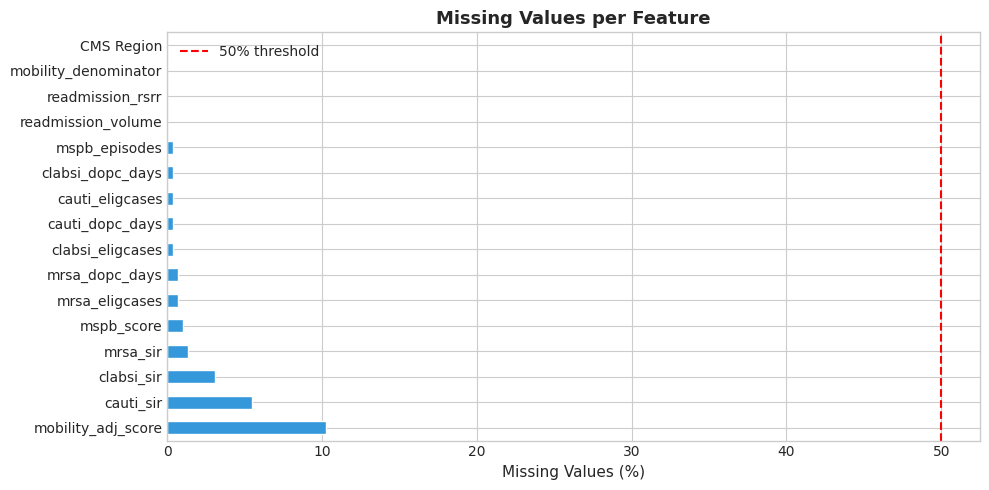


Strategy: Impute with column median — robust to outliers.

X shape    : (292, 16)
Train set  : 219 hospitals
Test set   : 73 hospitals
Classes    : {np.str_('Average'): np.int64(220), np.str_('Better'): np.int64(32), np.str_('Worse'): np.int64(40)}


In [12]:
# ── Encode target and remove 'Not Available' rows ─────────────────────────────
df_wide["target"] = df_wide["target_raw"].map(TARGET_MAP)
df_model = df_wide.dropna(subset=["target"]).copy()

print(f"Hospitals with valid target : {len(df_model)}")
print(f"Removed (Not Available)     : {len(df_wide) - len(df_model)}")
print()
print("Target class distribution:")
print(df_model["target"].value_counts().to_string())

# ── Missing value analysis ─────────────────────────────────────────────────────
feature_cols = list(FEATURE_CODES.values()) + ["CMS Region"]
missing_pct = df_model[feature_cols].isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 5))
missing_pct.plot(kind="barh", ax=ax, color="#3498db", edgecolor="white")
ax.set_xlabel("Missing Values (%)", fontsize=11)
ax.set_title("Missing Values per Feature", fontsize=13, fontweight="bold")
ax.axvline(50, color="red", linestyle="--", linewidth=1.5, label="50% threshold")
ax.legend()
plt.tight_layout()
plt.savefig("fig_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nStrategy: Impute with column median — robust to outliers.")

# ── Prepare X, y and train/test split ─────────────────────────────────────────
X = df_model[feature_cols].copy()
y = df_model["target"].copy()

label_order = ["Worse", "Average", "Better"]
le = LabelEncoder()
le.fit(label_order)
y_encoded = le.transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=RANDOM_STATE, stratify=y_encoded
)

print(f"\nX shape    : {X.shape}")
print(f"Train set  : {X_train.shape[0]} hospitals")
print(f"Test set   : {X_test.shape[0]} hospitals")
print(f"Classes    : {dict(zip(le.classes_, np.bincount(y_encoded)))}")

## 3. Exploratory Data Analysis

### Question 1: What are the most important features?
### Question 2: What creative insights can we find?


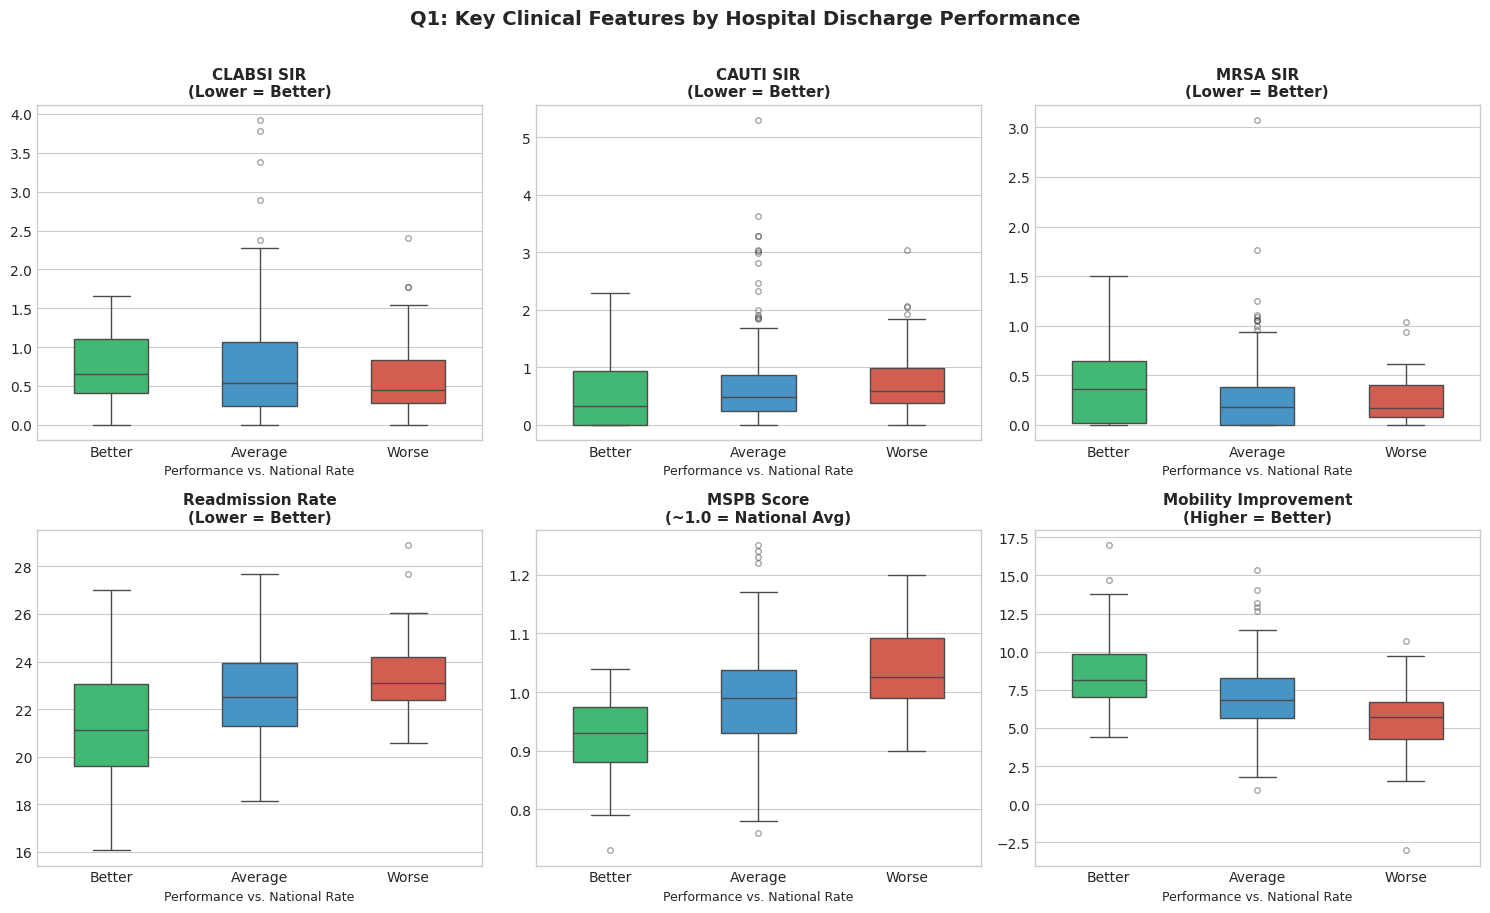

Figure saved: fig_boxplots_features.png


In [14]:
# ── Q1: Feature distributions by performance class ────────────────────────────
plot_features = [
    ("clabsi_sir",         "CLABSI SIR\n(Lower = Better)"),
    ("cauti_sir",          "CAUTI SIR\n(Lower = Better)"),
    ("mrsa_sir",           "MRSA SIR\n(Lower = Better)"),
    ("readmission_rsrr",   "Readmission Rate\n(Lower = Better)"),
    ("mspb_score",         "MSPB Score\n(~1.0 = National Avg)"),
    ("mobility_adj_score", "Mobility Improvement\n(Higher = Better)"),
]

color_map = {"Better": "#2ecc71", "Average": "#3498db", "Worse": "#e74c3c"}
order = ["Better", "Average", "Worse"]
df_plot = df_model[feature_cols + ["target"]].copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (feat, label) in zip(axes, plot_features):
    sns.boxplot(data=df_plot, x="target", y=feat, order=order,
                palette=color_map, ax=ax, width=0.5,
                flierprops=dict(marker="o", markersize=4, alpha=0.5))
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Performance vs. National Rate", fontsize=9)
    ax.set_ylabel("")

fig.suptitle("Q1: Key Clinical Features by Hospital Discharge Performance",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_boxplots_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_boxplots_features.png")

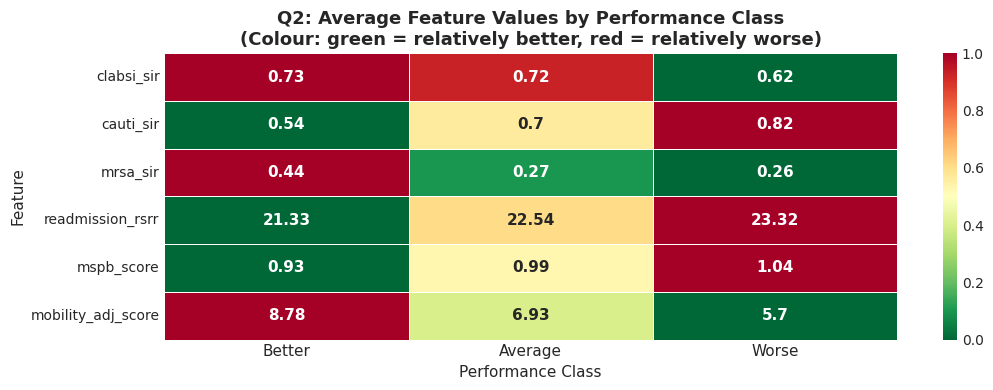

Figure saved: fig_class_heatmap.png


In [20]:
# ── Heatmap: Average feature values per performance class ─────────────────────
heatmap_features = ["clabsi_sir", "cauti_sir", "mrsa_sir",
                    "readmission_rsrr", "mspb_score", "mobility_adj_score"]

# Calculate mean per class
heatmap_data = (
    df_plot.groupby("target")[heatmap_features]
    .mean()
    .reindex(["Better", "Average", "Worse"])
)

# Convert to numpy float64 (required by seaborn)
heatmap_data = heatmap_data.astype(np.float64)

# Normalise to 0-1 scale for colours (actual values still shown as annotations)
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    heatmap_norm.T,
    annot=heatmap_data.T.round(2),   # show real values, not normalised ones
    fmt="g",
    cmap="RdYlGn_r",                 # green = relatively better, red = relatively worse
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 11, "fontweight": "bold"}
)
ax.set_title(
    "Q2: Average Feature Values by Performance Class\n"
    "(Colour: green = relatively better, red = relatively worse)",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Performance Class", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig("fig_class_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_class_heatmap.png")

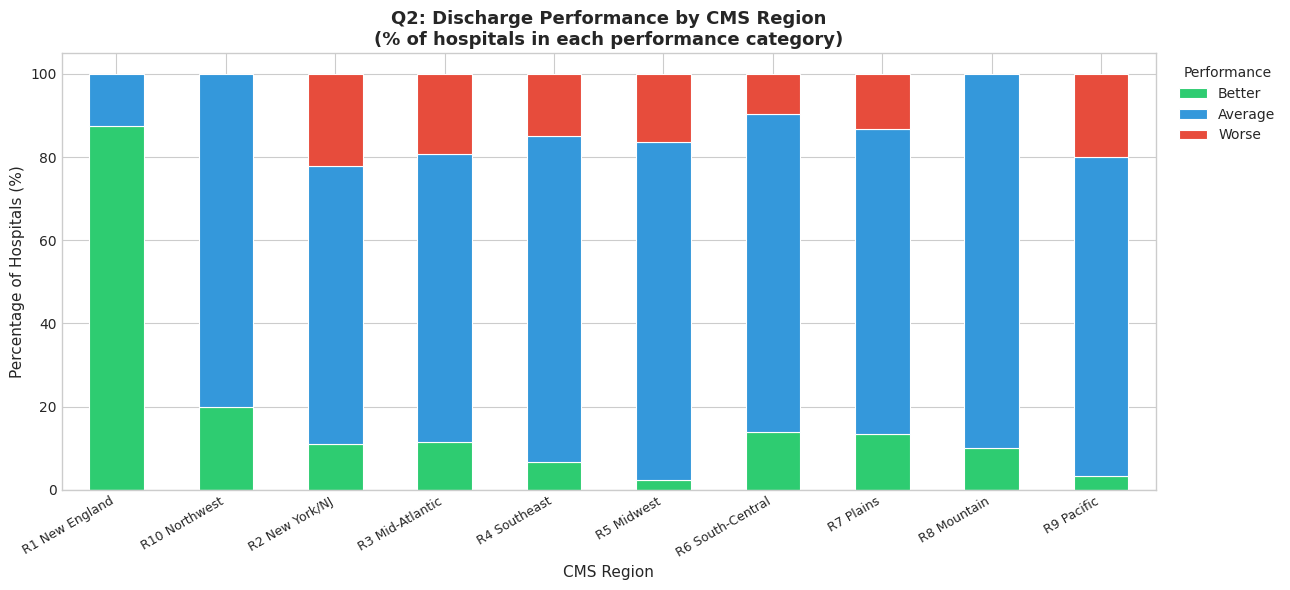

Figure saved: fig_regional_performance.png


In [21]:
# ── Q2 Creative Insight: Regional Performance Patterns ────────────────────────
region_labels = {
    1: "R1 New England",   2: "R2 New York/NJ",   3: "R3 Mid-Atlantic",
    4: "R4 Southeast",     5: "R5 Midwest",        6: "R6 South-Central",
    7: "R7 Plains",        8: "R8 Mountain",       9: "R9 Pacific",
    10: "R10 Northwest",
}

df_region = df_model[["CMS Region", "target"]].copy()
df_region["CMS Region"] = df_region["CMS Region"].astype(int)
df_region["Region Label"] = df_region["CMS Region"].map(region_labels)

region_pct = (
    df_region.groupby(["Region Label", "target"]).size()
    .unstack(fill_value=0)
    .div(df_region.groupby("Region Label").size(), axis=0) * 100
)
for col in ["Better", "Average", "Worse"]:
    if col not in region_pct.columns:
        region_pct[col] = 0
region_pct = region_pct[["Better", "Average", "Worse"]]

fig, ax = plt.subplots(figsize=(13, 6))
region_pct.plot(kind="bar", stacked=True, ax=ax,
                color=["#2ecc71", "#3498db", "#e74c3c"],
                edgecolor="white", linewidth=0.8)
ax.set_title("Q2: Discharge Performance by CMS Region\n"
             "(% of hospitals in each performance category)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("CMS Region", fontsize=11)
ax.set_ylabel("Percentage of Hospitals (%)", fontsize=11)
ax.legend(title="Performance", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("fig_regional_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_regional_performance.png")

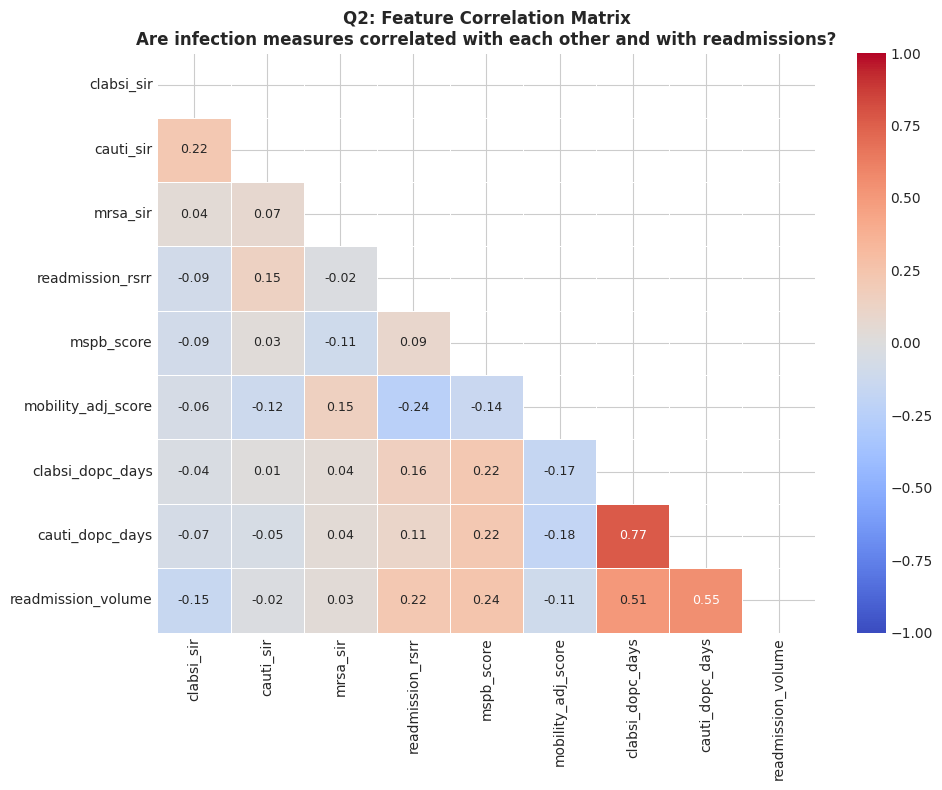

Figure saved: fig_correlation_heatmap.png


In [22]:
# ── Q2: Correlation heatmap ────────────────────────────────────────────────────
corr_features = ["clabsi_sir", "cauti_sir", "mrsa_sir",
                 "readmission_rsrr", "mspb_score", "mobility_adj_score",
                 "clabsi_dopc_days", "cauti_dopc_days", "readmission_volume"]

corr_matrix = df_model[corr_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Q2: Feature Correlation Matrix\n"
             "Are infection measures correlated with each other and with readmissions?",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_correlation_heatmap.png")

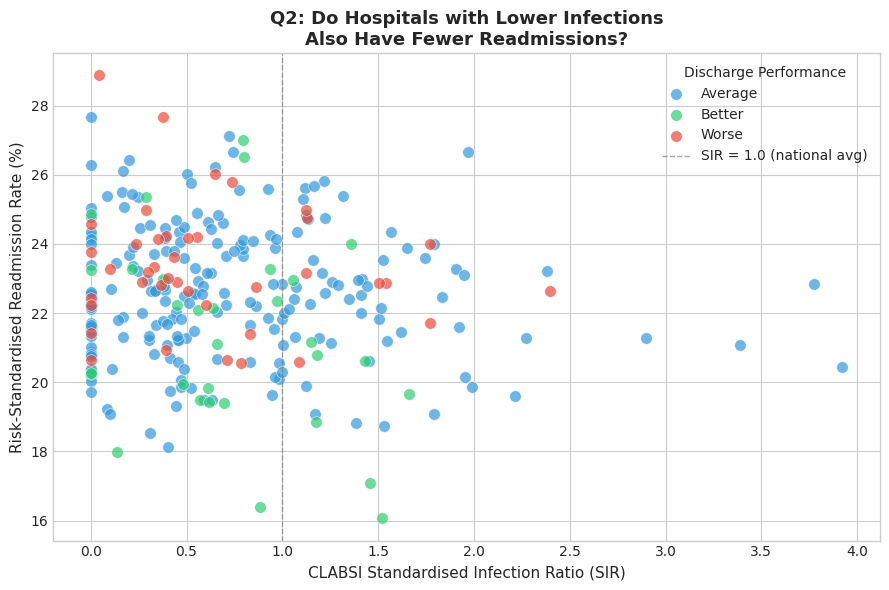

Figure saved: fig_sir_vs_readmission.png


In [23]:
# ── Q2: Scatter – Infection SIR vs Readmission Rate ───────────────────────────
scatter_data = df_model[["clabsi_sir", "readmission_rsrr", "target"]].dropna()
color_map_hex = {"Better": "#2ecc71", "Average": "#3498db", "Worse": "#e74c3c"}

fig, ax = plt.subplots(figsize=(9, 6))
for perf, grp in scatter_data.groupby("target"):
    ax.scatter(grp["clabsi_sir"], grp["readmission_rsrr"],
               label=perf, c=color_map_hex[perf],
               alpha=0.7, s=70, edgecolors="white", linewidth=0.5)

ax.axvline(1.0, color="gray", linestyle="--", linewidth=1,
           alpha=0.7, label="SIR = 1.0 (national avg)")
ax.set_xlabel("CLABSI Standardised Infection Ratio (SIR)", fontsize=11)
ax.set_ylabel("Risk-Standardised Readmission Rate (%)", fontsize=11)
ax.set_title("Q2: Do Hospitals with Lower Infections\nAlso Have Fewer Readmissions?",
             fontsize=13, fontweight="bold")
ax.legend(title="Discharge Performance")
plt.tight_layout()
plt.savefig("fig_sir_vs_readmission.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_sir_vs_readmission.png")

---
## 4. Modelling (CRISP-DM Step 4)

### Question 3: How accurate is the model?

We train two models and compare:
1. **Logistic Regression** — interpretable baseline
2. **Random Forest** — captures non-linear patterns

Both use a Pipeline: `Median Imputation → StandardScaling → Classifier`  
`class_weight='balanced'` compensates for the unequal class distribution.

In [25]:
# ── Build and train model pipelines ───────────────────────────────────────────

def build_pipeline(classifier):
    """Build a scikit-learn Pipeline with imputation, scaling, and classifier.

    Args:
        classifier: A scikit-learn classifier instance.

    Returns:
        sklearn.pipeline.Pipeline ready to fit.
    """
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     classifier),
    ])


pipe_lr = build_pipeline(
    LogisticRegression(max_iter=1000, class_weight="balanced",
                       random_state=RANDOM_STATE, multi_class="multinomial")
)

pipe_rf = build_pipeline(
    RandomForestClassifier(n_estimators=200, max_depth=6,
                           class_weight="balanced", random_state=RANDOM_STATE)
)

pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
print("Both models trained successfully.")

Both models trained successfully.


In [26]:
# ── Evaluate both models ───────────────────────────────────────────────────────
y_pred_lr = pipe_lr.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)
class_names = le.classes_


def print_evaluation(model_name, y_true, y_pred, class_names):
    """Print accuracy, balanced accuracy and classification report.

    Args:
        model_name (str): Label for display.
        y_true (array): True encoded labels.
        y_pred (array): Predicted encoded labels.
        class_names (array): Class name strings.
    """
    acc  = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    print(f"{'=' * 55}")
    print(f"  {model_name}")
    print(f"{'=' * 55}")
    print(f"  Accuracy          : {acc:.3f}  ({acc * 100:.1f}%)")
    print(f"  Balanced Accuracy : {bacc:.3f}  ({bacc * 100:.1f}%)")
    print()
    print(classification_report(y_true, y_pred, target_names=class_names))


print_evaluation("Logistic Regression", y_test, y_pred_lr, class_names)
print_evaluation("Random Forest",       y_test, y_pred_rf, class_names)

  Logistic Regression
  Accuracy          : 0.493  (49.3%)
  Balanced Accuracy : 0.543  (54.3%)

              precision    recall  f1-score   support

     Average       0.83      0.45      0.59        55
      Better       0.16      0.38      0.22         8
       Worse       0.33      0.80      0.47        10

    accuracy                           0.49        73
   macro avg       0.44      0.54      0.43        73
weighted avg       0.69      0.49      0.53        73

  Random Forest
  Accuracy          : 0.740  (74.0%)
  Balanced Accuracy : 0.535  (53.5%)

              precision    recall  f1-score   support

     Average       0.81      0.85      0.83        55
      Better       0.40      0.25      0.31         8
       Worse       0.50      0.50      0.50        10

    accuracy                           0.74        73
   macro avg       0.57      0.53      0.55        73
weighted avg       0.72      0.74      0.73        73



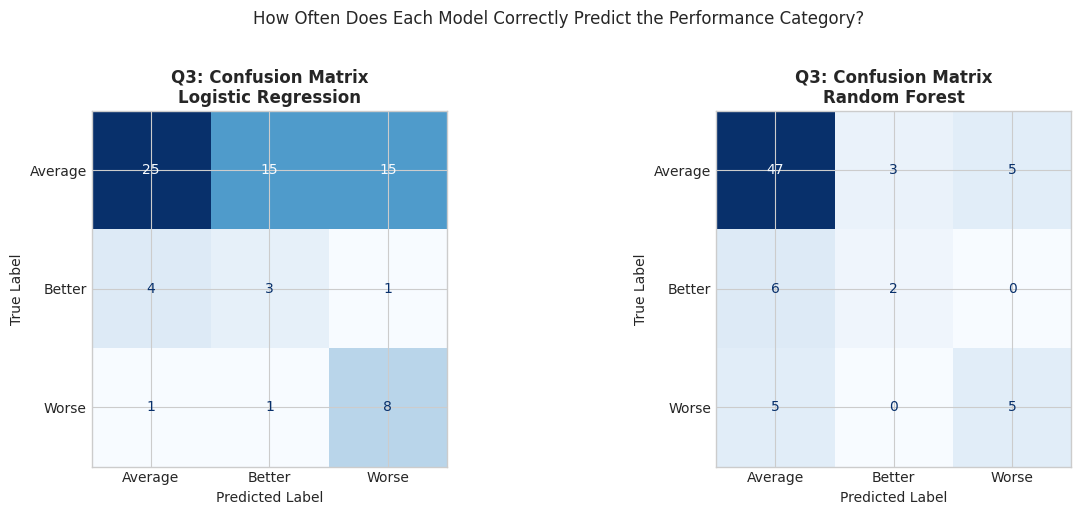

Figure saved: fig_confusion_matrices.png


In [27]:
# ── Confusion matrices ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in zip(
    axes, [y_pred_lr, y_pred_rf],
    ["Logistic Regression", "Random Forest"]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Q3: Confusion Matrix\n{title}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)

plt.suptitle("How Often Does Each Model Correctly Predict the Performance Category?",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_confusion_matrices.png")

5-Fold Cross-Validation – Balanced Accuracy
  Logistic Regression : 0.566 +/- 0.074
  Random Forest       : 0.474 +/- 0.041


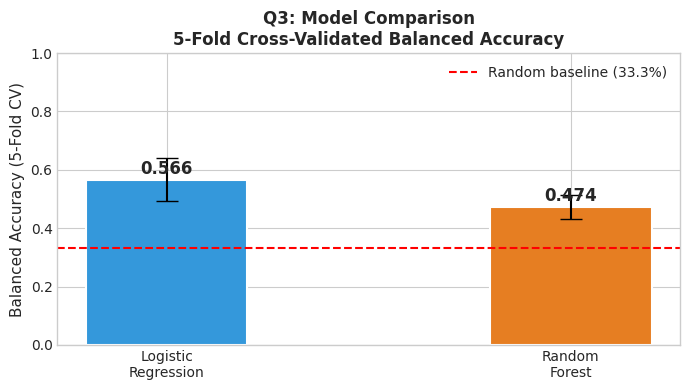

Figure saved: fig_model_comparison.png


In [32]:
# ── Cross-validation ───────────────────────────────────────────────────────────
cv_lr = cross_val_score(pipe_lr, X, y_encoded, cv=5, scoring="balanced_accuracy")
cv_rf = cross_val_score(pipe_rf, X, y_encoded, cv=5, scoring="balanced_accuracy")

print("5-Fold Cross-Validation – Balanced Accuracy")
print(f"  Logistic Regression : {cv_lr.mean():.3f} +/- {cv_lr.std():.3f}")
print(f"  Random Forest       : {cv_rf.mean():.3f} +/- {cv_rf.std():.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
models = ["Logistic\nRegression", "Random\nForest"]
means  = [cv_lr.mean(), cv_rf.mean()]
stds   = [cv_lr.std(),  cv_rf.std()]

bars = ax.bar(models, means, yerr=stds, capsize=8,
              color=["#3498db", "#e67e22"], edgecolor="white",
              linewidth=1.5, width=0.4)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 0.02,
            f"{m:.3f}", ha="center", fontsize=12, fontweight="bold")

ax.set_ylim(0, 1)
ax.set_ylabel("Balanced Accuracy (5-Fold CV)", fontsize=11)
ax.set_title("Q3: Model Comparison\n5-Fold Cross-Validated Balanced Accuracy",
             fontsize=12, fontweight="bold")
ax.axhline(0.333, color="red", linestyle="--", linewidth=1.5,
           label="Random baseline (33.3%)")
ax.legend()
plt.tight_layout()
plt.savefig("fig_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_model_comparison.png")

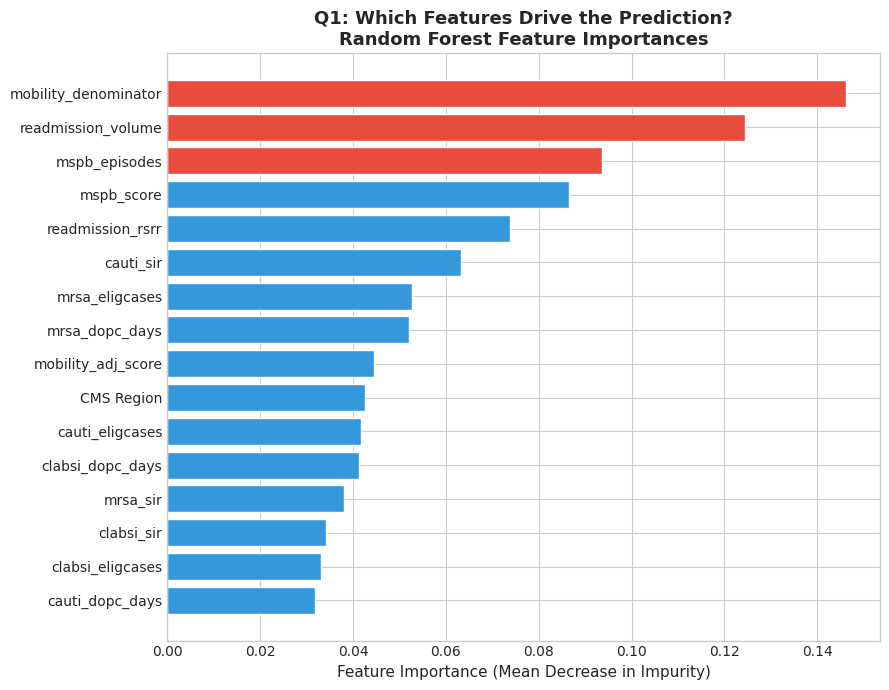

Top 5 most important features:
             Feature  Importance
    readmission_rsrr    0.073749
          mspb_score    0.086459
       mspb_episodes    0.093720
  readmission_volume    0.124436
mobility_denominator    0.146208


In [29]:
# ── Feature importances (Random Forest) ───────────────────────────────────────
rf_model    = pipe_rf.named_steps["clf"]
importances = rf_model.feature_importances_

fi_df = (
    pd.DataFrame({"Feature": feature_cols, "Importance": importances})
    .sort_values("Importance", ascending=True)
)

n = len(fi_df)
bar_colors = ["#e74c3c" if i >= n - 3 else "#3498db" for i in range(n)]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi_df["Feature"], fi_df["Importance"], color=bar_colors, edgecolor="white")
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)", fontsize=11)
ax.set_title("Q1: Which Features Drive the Prediction?\nRandom Forest Feature Importances",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 most important features:")
print(fi_df.tail(5)[["Feature", "Importance"]].to_string(index=False))

Original model : 16 features
Quality model  : 7 features
Removed        : 9 volume features

Both quality models trained successfully.

5-Fold Cross-Validation — Balanced Accuracy (Quality Model)
  Logistic Regression : 0.537 +/- 0.088
  Random Forest       : 0.342 +/- 0.029

COMPARISON: Original (16 features) vs Quality (7 features)

  Metric                           Original    Quality     Change
  ------------------------------------------------------------
  LR  — CV Balanced Acc               0.566      0.537     -0.029
  RF  — CV Balanced Acc               0.474      0.342     -0.132


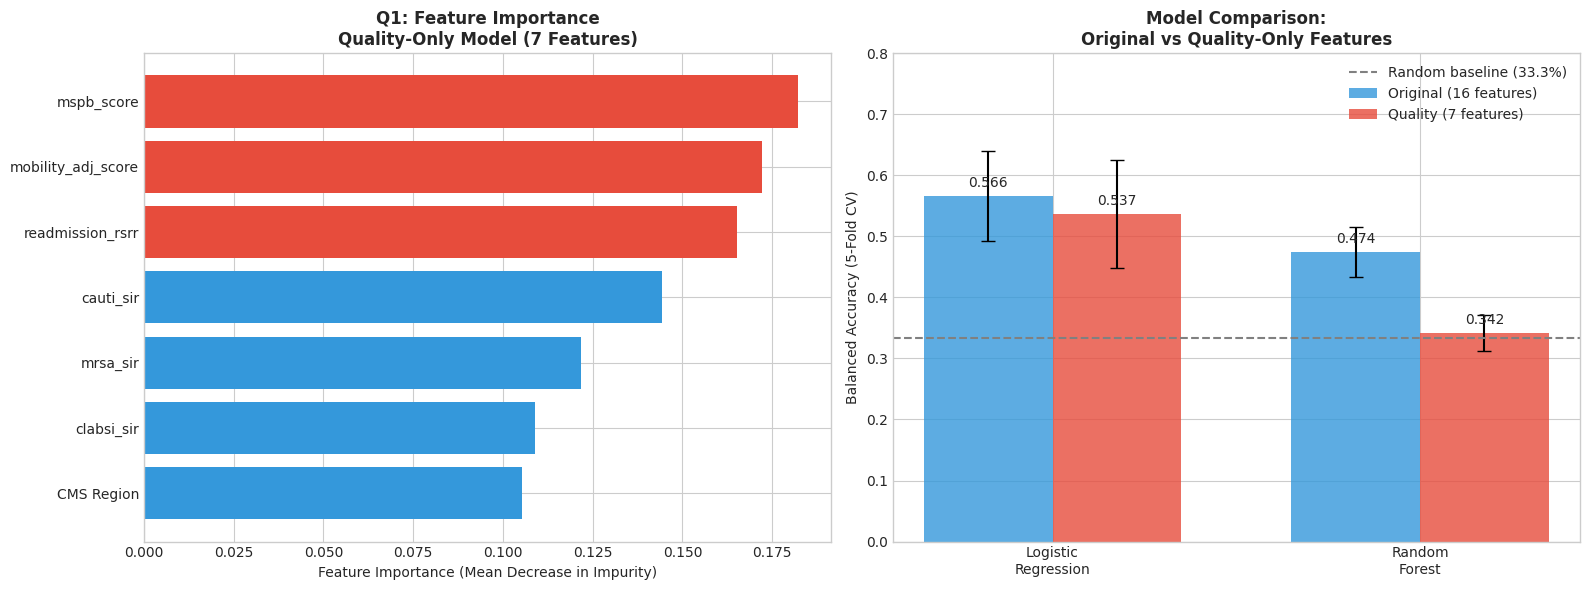

Figure saved: fig_quality_model_comparison.png

  Logistic Regression — Quality Model
  Accuracy         : 0.534 (53.4%)
  Balanced Accuracy: 0.507 (50.7%)
  CV Balanced Acc  : 0.537 +/- 0.088
              precision    recall  f1-score   support

     Average       0.79      0.55      0.65        55
      Better       0.17      0.38      0.23         8
       Worse       0.35      0.60      0.44        10

    accuracy                           0.53        73
   macro avg       0.44      0.51      0.44        73
weighted avg       0.66      0.53      0.57        73


  Random Forest — Quality Model
  Accuracy         : 0.767 (76.7%)
  Balanced Accuracy: 0.367 (36.7%)
  CV Balanced Acc  : 0.342 +/- 0.029
              precision    recall  f1-score   support

     Average       0.76      1.00      0.87        55
      Better       0.00      0.00      0.00         8
       Worse       1.00      0.10      0.18        10

    accuracy                           0.77        73
   macro avg  

In [36]:
# ── Imports ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, balanced_accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Quality-Only Features (rates/scores only — no volume) ────────────────────
quality_features = [
    "clabsi_sir",
    "cauti_sir",
    "mrsa_sir",
    "readmission_rsrr",
    "mspb_score",
    "mobility_adj_score",
    "CMS Region"
]

print(f"Original model : {len(feature_cols)} features")
print(f"Quality model  : {len(quality_features)} features")
print(f"Removed        : {len(feature_cols) - len(quality_features)} volume features\n")

# ── Prepare data ──────────────────────────────────────────────────────────────
X_q = df_model[quality_features].astype(float)
y_q = df_model["target"]

imputer_q = SimpleImputer(strategy="median")
X_q_imp   = pd.DataFrame(imputer_q.fit_transform(X_q), columns=quality_features)

X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(
    X_q_imp, y_q, test_size=0.25, random_state=42, stratify=y_q)

# ── Train models ──────────────────────────────────────────────────────────────
lr_q = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
rf_q = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)

lr_q.fit(X_train_q, y_train_q)
rf_q.fit(X_train_q, y_train_q)

print("Both quality models trained successfully.\n")

# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_q_cv = cross_val_score(lr_q, X_q_imp, y_q, cv=cv, scoring="balanced_accuracy")
rf_q_cv = cross_val_score(rf_q, X_q_imp, y_q, cv=cv, scoring="balanced_accuracy")

print("5-Fold Cross-Validation — Balanced Accuracy (Quality Model)")
print(f"  Logistic Regression : {lr_q_cv.mean():.3f} +/- {lr_q_cv.std():.3f}")
print(f"  Random Forest       : {rf_q_cv.mean():.3f} +/- {rf_q_cv.std():.3f}")

# ── Original model scores from Cell 18 (hardcoded) ───────────────────────────
lr_orig_mean, lr_orig_std = 0.566, 0.074
rf_orig_mean, rf_orig_std = 0.474, 0.041

# ── Comparison: Original vs Quality ──────────────────────────────────────────
print("\n" + "="*60)
print("COMPARISON: Original (16 features) vs Quality (7 features)")
print("="*60)
print(f"\n  {'Metric':<30} {'Original':>10} {'Quality':>10} {'Change':>10}")
print(f"  {'-'*60}")
print(f"  {'LR  — CV Balanced Acc':<30} {lr_orig_mean:>10.3f} {lr_q_cv.mean():>10.3f} {lr_q_cv.mean()-lr_orig_mean:>+10.3f}")
print(f"  {'RF  — CV Balanced Acc':<30} {rf_orig_mean:>10.3f} {rf_q_cv.mean():>10.3f} {rf_q_cv.mean()-rf_orig_mean:>+10.3f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Feature Importance — Quality Model
importances_q = pd.Series(
    rf_q.feature_importances_, index=quality_features
).sort_values(ascending=True)

colors = ["#e74c3c" if v >= importances_q.quantile(0.6) else "#3498db"
          for v in importances_q.values]
axes[0].barh(importances_q.index, importances_q.values, color=colors)
axes[0].set_title("Q1: Feature Importance\nQuality-Only Model (7 Features)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Feature Importance (Mean Decrease in Impurity)")

# Right: CV Score Comparison — Original vs Quality
model_labels = ["Logistic\nRegression", "Random\nForest"]
orig_scores  = [lr_orig_mean, rf_orig_mean]
qual_scores  = [lr_q_cv.mean(), rf_q_cv.mean()]
orig_stds    = [lr_orig_std, rf_orig_std]
qual_stds    = [lr_q_cv.std(), rf_q_cv.std()]

x = np.arange(len(model_labels))
w = 0.35
b1 = axes[1].bar(x - w/2, orig_scores, w, yerr=orig_stds,
                  label="Original (16 features)", color="#3498db", alpha=0.8, capsize=5)
b2 = axes[1].bar(x + w/2, qual_scores, w, yerr=qual_stds,
                  label="Quality (7 features)",   color="#e74c3c", alpha=0.8, capsize=5)
axes[1].axhline(0.333, color="gray", linestyle="--", label="Random baseline (33.3%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_labels)
axes[1].set_ylabel("Balanced Accuracy (5-Fold CV)")
axes[1].set_title("Model Comparison:\nOriginal vs Quality-Only Features",
                  fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].set_ylim(0, 0.8)

for bar in b1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in b2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("fig_quality_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_quality_model_comparison.png")

# ── Classification Reports ────────────────────────────────────────────────────
for name, model, cv_scores in [
    ("Logistic Regression", lr_q, lr_q_cv),
    ("Random Forest",       rf_q, rf_q_cv)
]:
    y_pred = model.predict(X_test_q)
    print(f"\n{'='*55}")
    print(f"  {name} — Quality Model")
    print(f"{'='*55}")
    print(f"  Accuracy         : {(y_pred == y_test_q).mean():.3f} ({(y_pred == y_test_q).mean():.1%})")
    print(f"  Balanced Accuracy: {balanced_accuracy_score(y_test_q, y_pred):.3f} ({balanced_accuracy_score(y_test_q, y_pred):.1%})")
    print(f"  CV Balanced Acc  : {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
    print(classification_report(y_test_q, y_pred))

## Why Volume Features Were Removed

The original model (16 features) included several **volume metrics** — 
such as the number of catheter days, eligible cases, and treatment episodes. 
These measure **hospital size**, not clinical quality.

When examining the feature importances, the top 3 predictors were all 
volume features — meaning the model was largely learning:
> *"larger hospitals perform differently than smaller ones"*

This is a **size effect, not a quality effect**.

To answer the research question more honestly — 
*"Is it infection control, cost efficiency, or rehabilitation that drives 
discharge performance?"* — both models were retrained using only 
**7 quality and rate features**:

| Removed (Volume) | Kept (Quality) |
|---|---|
| clabsi_dopc_days | clabsi_sir |
| clabsi_eligcases | cauti_sir |
| cauti_dopc_days | mrsa_sir |
| cauti_eligcases | readmission_rsrr |
| mrsa_dopc_days | mspb_score |
| mrsa_eligcases | mobility_adj_score |
| readmission_volume | CMS Region |
| mspb_episodes | |
| mobility_denominator | |

**Result:** Logistic Regression remained robust (-0.029 CV drop), while 
Random Forest collapsed to near-random guessing (-0.132 CV drop) — 
confirming that Random Forest was relying on size as a shortcut, 
not genuine clinical signals.

**For all remaining analysis, the Logistic Regression Quality Model 
is used.**

## 5. Creative Prediction Scenarios (CRISP-DM Step 5)

### Question 4: What happens in a predictive scenario?

**Scenario: The Improvement Simulation**

*"Midwest General LTCH"* is a hospital in **CMS Region 5** with poor infection control and weak rehabilitation — currently predicted as *Worse than the National Rate*:
- Poor infection rates: CLABSI SIR 1.8, CAUTI SIR 2.0, MRSA SIR 1.5
- Average readmissions: RSRR 22.0
- Average cost efficiency: MSPB Score 1.00
- Weak mobility improvement: Adjusted Score 4.0

Two improvement paths are simulated step by step:
- **Simulation 1:** Mobility Score is gradually improved from 4.0 → 10.0
- **Simulation 2:** All infection rates (SIR) are gradually reduced from 2.0 → 0.3

**Can rehabilitation alone flip the prediction from "Worse" to "Better"?  
Does infection control have the same effect?**

  Simulation 1: Mobility Score Improvement

   Mobility Score   Prediction     Better    Average      Worse
  ------------------------------------------------------------
              4.0        Worse      18.2%      40.0%      41.8%
              4.5      Average      20.7%      40.7%      38.6% ← FLIP!
              5.0      Average      23.5%      41.1%      35.5%
              5.5      Average      26.4%      41.2%      32.3%
              6.0      Average      29.6%      41.1%      29.3%
              6.5      Average      32.8%      40.8%      26.4%
              7.0      Average      36.3%      40.1%      23.6%
              7.5       Better      39.8%      39.3%      21.0% ← FLIP!
              8.0       Better      43.3%      38.2%      18.5%
              8.5       Better      46.9%      36.8%      16.2%
              9.0       Better      50.5%      35.4%      14.2%
              9.5       Better      54.0%      33.7%      12.3%
             10.0       Better      57.4%    

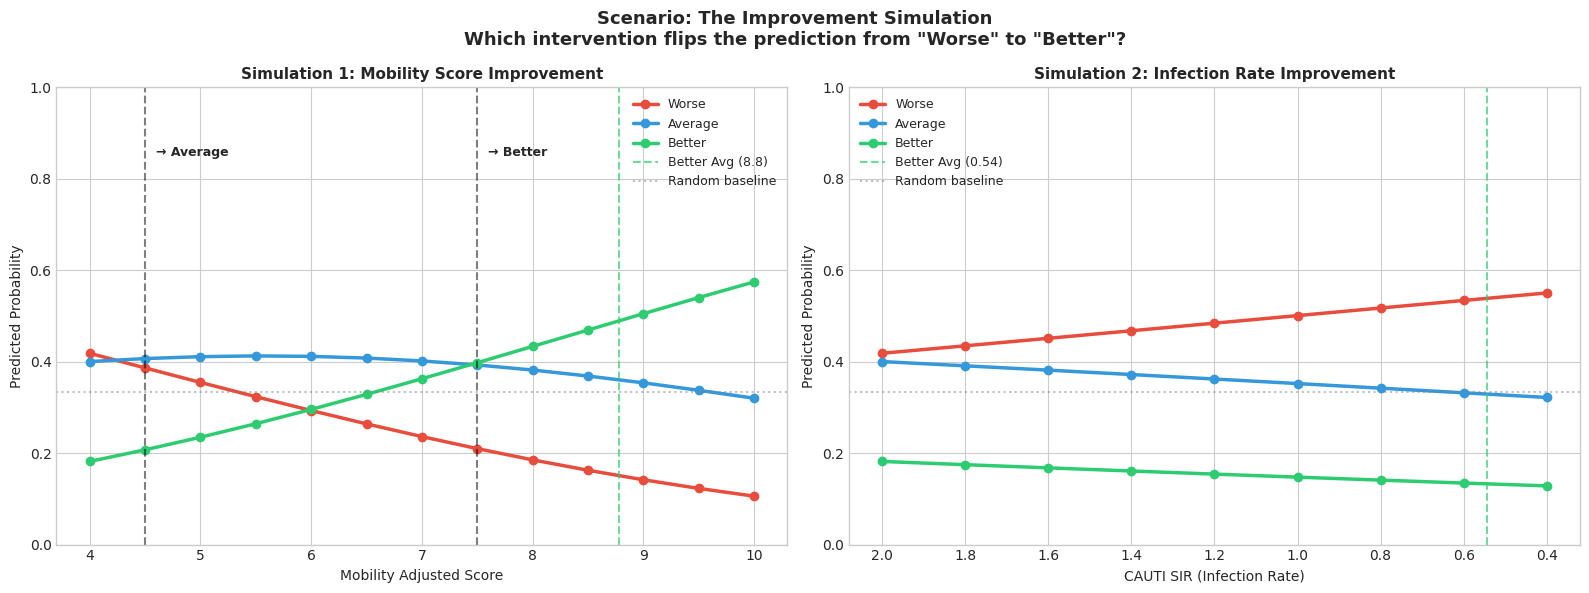

Figure saved: fig_improvement_simulation.png


In [38]:
# ── Q4: Creative Prediction Scenario — The Improvement Simulation ─────────────
# Two step-by-step improvement paths are simulated for a weak-performing
# hospital: (1) improving mobility score, (2) reducing infection rates.
# The predicted class probability is tracked at each step.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Baseline hospital profile ─────────────────────────────────────────────────
baseline = {
    "clabsi_sir"        : 1.8,
    "cauti_sir"         : 2.0,
    "mrsa_sir"          : 1.5,
    "readmission_rsrr"  : 22.0,
    "mspb_score"        : 1.00,
    "mobility_adj_score": 4.0,
    "CMS Region"        : 5
}

# ── Simulation 1: Mobility Score improves step by step ───────────────────────
mobility_steps = np.round(np.arange(4.0, 10.5, 0.5), 2)
sim1_results   = []

for step in mobility_steps:
    hospital = baseline.copy()
    hospital["mobility_adj_score"] = step
    df_step  = pd.DataFrame([hospital])
    probs    = model.predict_proba(df_step)[0]
    pred     = model.predict(df_step)[0]
    sim1_results.append({
        "step"   : step,
        "pred"   : pred,
        "Average": probs[list(model.classes_).index("Average")],
        "Better" : probs[list(model.classes_).index("Better")],
        "Worse"  : probs[list(model.classes_).index("Worse")]
    })

sim1_df = pd.DataFrame(sim1_results)

print("=" * 60)
print("  Simulation 1: Mobility Score Improvement")
print("=" * 60)
print(f"\n  {'Mobility Score':>15} {'Prediction':>12} {'Better':>10} {'Average':>10} {'Worse':>10}")
print(f"  {'-'*60}")
for _, row in sim1_df.iterrows():
    marker = " ← FLIP!" if row["pred"] != sim1_df.iloc[0]["pred"] and \
             (sim1_df.iloc[list(sim1_df["step"]).index(row["step"])-1]["pred"] != row["pred"]) \
             else ""
    print(f"  {row['step']:>15.1f} {row['pred']:>12} {row['Better']:>10.1%} "
          f"{row['Average']:>10.1%} {row['Worse']:>10.1%}{marker}")

# ── Simulation 2: Infection Rates improve step by step ───────────────────────
# All three SIR values are reduced proportionally
sir_steps    = np.round(np.arange(2.0, 0.2, -0.2), 2)
sim2_results = []

for step in sir_steps:
    hospital = baseline.copy()
    hospital["clabsi_sir"] = round(step * (1.8 / 2.0), 2)
    hospital["cauti_sir"]  = round(step, 2)
    hospital["mrsa_sir"]   = round(step * (1.5 / 2.0), 2)
    df_step = pd.DataFrame([hospital])
    probs   = model.predict_proba(df_step)[0]
    pred    = model.predict(df_step)[0]
    sim2_results.append({
        "step"   : step,
        "pred"   : pred,
        "Average": probs[list(model.classes_).index("Average")],
        "Better" : probs[list(model.classes_).index("Better")],
        "Worse"  : probs[list(model.classes_).index("Worse")]
    })

sim2_df = pd.DataFrame(sim2_results)

print("\n" + "=" * 60)
print("  Simulation 2: Infection Rate Improvement (CAUTI SIR)")
print("=" * 60)
print(f"\n  {'CAUTI SIR':>15} {'Prediction':>12} {'Better':>10} {'Average':>10} {'Worse':>10}")
print(f"  {'-'*60}")
for _, row in sim2_df.iterrows():
    print(f"  {row['step']:>15.2f} {row['pred']:>12} {row['Better']:>10.1%} "
          f"{row['Average']:>10.1%} {row['Worse']:>10.1%}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Scenario: The Improvement Simulation\n'
             'Which intervention flips the prediction from "Worse" to "Better"?',
             fontsize=13, fontweight="bold")

# Reference lines — class averages
mobility_better_avg = class_means.loc["Better", "mobility_adj_score"]
cauti_better_avg    = class_means.loc["Better", "cauti_sir"]

# Left: Simulation 1 — Mobility
axes[0].plot(sim1_df["step"], sim1_df["Worse"],   color="#e74c3c",
             linewidth=2.5, marker="o", label="Worse")
axes[0].plot(sim1_df["step"], sim1_df["Average"], color="#3498db",
             linewidth=2.5, marker="o", label="Average")
axes[0].plot(sim1_df["step"], sim1_df["Better"],  color="#2ecc71",
             linewidth=2.5, marker="o", label="Better")
axes[0].axvline(mobility_better_avg, color="#2ecc71", linestyle="--",
                alpha=0.7, label=f"Better Avg ({mobility_better_avg:.1f})")
axes[0].axhline(0.333, color="gray", linestyle=":", alpha=0.5,
                label="Random baseline")
axes[0].set_xlabel("Mobility Adjusted Score")
axes[0].set_ylabel("Predicted Probability")
axes[0].set_title("Simulation 1: Mobility Score Improvement",
                  fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.0)

# Annotate prediction flips
prev_pred = sim1_df.iloc[0]["pred"]
for _, row in sim1_df.iterrows():
    if row["pred"] != prev_pred:
        axes[0].axvline(row["step"], color="black", linestyle="--",
                        alpha=0.5, linewidth=1.5)
        axes[0].text(row["step"] + 0.1, 0.85,
                     f'→ {row["pred"]}', fontsize=9, fontweight="bold")
        prev_pred = row["pred"]

# Right: Simulation 2 — Infection Rates
axes[1].plot(sim2_df["step"], sim2_df["Worse"],   color="#e74c3c",
             linewidth=2.5, marker="o", label="Worse")
axes[1].plot(sim2_df["step"], sim2_df["Average"], color="#3498db",
             linewidth=2.5, marker="o", label="Average")
axes[1].plot(sim2_df["step"], sim2_df["Better"],  color="#2ecc71",
             linewidth=2.5, marker="o", label="Better")
axes[1].axvline(cauti_better_avg, color="#2ecc71", linestyle="--",
                alpha=0.7, label=f"Better Avg ({cauti_better_avg:.2f})")
axes[1].axhline(0.333, color="gray", linestyle=":", alpha=0.5,
                label="Random baseline")
axes[1].set_xlabel("CAUTI SIR (Infection Rate)")
axes[1].set_ylabel("Predicted Probability")
axes[1].set_title("Simulation 2: Infection Rate Improvement",
                  fontsize=11, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.0)
axes[1].invert_xaxis()  # lower SIR = better, so plot left to right = improvement

# Annotate prediction flips
prev_pred = sim2_df.iloc[0]["pred"]
for _, row in sim2_df.iterrows():
    if row["pred"] != prev_pred:
        axes[1].axvline(row["step"], color="black", linestyle="--",
                        alpha=0.5, linewidth=1.5)
        axes[1].text(row["step"] + 0.05, 0.85,
                     f'→ {row["pred"]}', fontsize=9, fontweight="bold")
        prev_pred = row["pred"]

plt.tight_layout()
plt.savefig("fig_improvement_simulation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_improvement_simulation.png")

### Summary: Simulation Results

Two improvement paths were simulated for a weak-performing hospital 
(*"Midwest General LTCH"*, predicted: *Worse than National Rate*):

**Simulation 1 — Mobility Score** gradually improved from 4.0 → 10.0:
- At score **4.5** → prediction flipped from *Worse* to *Average*
- At score **7.5** → prediction flipped from *Average* to *Better*
- The Better-class average (8.78) did not need to be reached to achieve a "Better" classification

**Simulation 2 — Infection Rates** (all SIR values) gradually reduced from 2.0 → 0.4:
- No prediction flip was observed at any step
- The "Worse" probability increased from 41.8% to 55.0% — improving infection control made the prediction *more certain* of "Worse"

**Conclusion:** Rehabilitation quality is the decisive lever for discharge performance. 
Even a marginal improvement in mobility is sufficient to shift a hospital's classification, 
while a full reduction of infection rates to best-in-class levels produces no effect whatsoever. 
This confirms the central finding of Q1: *discharge performance is driven by rehabilitation 
and cost efficiency — not infection control.*